# Predicción de asistencia
Esta parte es sólamente una muestra de cómo se puede aplicar nuestro proyecto de Bases de Datos al análisis predictivo de asistencia.

In [1]:
#Importamos las librerías necesarias:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline

Dado que tenemos 20 temporadas, vamos a hacer un modelo de predicción a través de regresión lineal, entrenarlo con las primeras 17 temporadas, y luego probarlo con las otras tres.

In [2]:
#Cargamos el dataset de entrenamiento (primeras 17 temporadas)
df_train = pd.read_csv("train.csv")
df_train.head()

,id,team_id,season_id,wins,losses,points_for,points_against,points_differential,margin_of_victory,strength_of_schedule,simple_rating,offensive_ranking,defensive_ranking,made_playoffs,id.1,team_id.1,season_id.1,home_attendance_total,away_attendance_total,total_attendance
0,337,25,10,9,7,348,236,112,7.0,1.6,8.6,1,8,t,1,25,10,616420,499524,1115944
1,153,32,5,7,9,483,435,48,3.0,2.3,5.3,10,-5,f,2,32,5,623010,527718,1150728
2,387,29,12,8,8,369,347,22,1.4,0.3,1.6,1,1,f,3,29,12,684096,574875,1258971
3,11,1,1,11,5,397,371,26,1.6,0.3,1.9,4,-2,t,4,1,1,513322,515940,1029262
4,386,19,12,5,11,288,367,-79,-4.9,0.8,-4.1,-4,0,f,5,19,12,615368,542973,1158341


In [3]:
#Cambiamos made_playoffs a binario
df_train["made_playoffs"] = df_train["made_playoffs"].replace({"t": 1, "f": 0})

C:\Users\isaac\AppData\Local\Temp\ipykernel_23200\1833042053.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train["made_playoffs"] = df_train["made_playoffs"].replace({"t": 1, "f": 0})


In [4]:
#Revisamos que no haya duplicados
df_train.duplicated().sum()

np.int64(0)

In [5]:
#Revisamos si hay nulos en alguna columna
df_train.isnull().sum()

id                       0
team_id                  0
season_id                0
wins                     0
losses                   0
points_for               0
points_against           0
points_differential      0
margin_of_victory        0
strength_of_schedule     0
simple_rating            0
offensive_ranking        0
defensive_ranking        0
made_playoffs            0
id.1                     0
team_id.1                0
season_id.1              0
home_attendance_total    0
away_attendance_total    0
total_attendance         0
dtype: int64

Ahora, definimos variables independientes y dependientes. Queremos predecir total_attendance (la asistencia total en una temporada) basado en:
wins,
points_for,
margin_of_victory,
offensive_ranking,
defensive_ranking,
made_playoffs

Omitimos losses pues al haber 16 juegos de temporada regular, losses es dependiente de wins y sesgaría el modelo (los empates son tan raros que son despreciables).

Omitimos points_against y points_differential porque son dependientes de points_for y margin_of_victory.

Omitimos strength_of_schedule al no considerarlo relevante para la asistencia.

Omitimos simple rating pues es dependiente de offensive_ranking y defensive_ranking.


In [6]:
# Creamos dataframes de variable independiente y dependiente:
X_train = df_train[["wins", "points_for", "margin_of_victory", "offensive_ranking", "defensive_ranking", "made_playoffs"]]
y_train = df_train["total_attendance"]

In [7]:
#Cargamos el dataset de prueba (últimas 3 temporadas)
df_test = pd.read_csv("test.csv")
df_test.head()

,id,team_id,season_id,wins,losses,points_for,points_against,points_differential,margin_of_victory,strength_of_schedule,simple_rating,offensive_ranking,defensive_ranking,made_playoffs,id.1,team_id.1,season_id.1,home_attendance_total,away_attendance_total,total_attendance
0,604,2,18,7,9,290,349,-59,-3.7,-1.3,-5.0,-4,-1,f,15,2,18,425937,552316,978253
1,653,16,20,13,3,458,341,117,7.3,0.0,7.4,5,2,t,30,16,20,584660,532397,1117057
2,648,22,20,11,5,405,398,7,0.4,2.3,2.7,3,0,t,31,22,20,551927,549722,1101649
3,635,9,19,10,6,433,344,89,5.6,-2.2,3.4,4,-1,t,40,9,19,473598,532763,1006361
4,606,17,18,13,3,406,308,98,6.1,-1.1,5.0,3,2,t,44,17,18,499768,535723,1035491


In [8]:
#Cambiamos made_playoffs a binario
df_test["made_playoffs"] = df_test["made_playoffs"].replace({"t": 1, "f": 0})

C:\Users\isaac\AppData\Local\Temp\ipykernel_23200\2952575797.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test["made_playoffs"] = df_test["made_playoffs"].replace({"t": 1, "f": 0})


In [9]:
# Creamos dataframes de variable independiente y dependiente:
X_test = df_test[["wins", "points_for", "margin_of_victory", "offensive_ranking", "defensive_ranking", "made_playoffs"]]
y_test = df_test["total_attendance"]

In [10]:
# Aplicamos normalización (de escala, no descomposición de relaciones)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


La normalización se ajusta con respecto a los datos de prueba pero se aplica a los datos de entrenamiento también. Esto se hace para evitar data leakage al modelo cuando lo creemos.

In [11]:
# Creamos y entrenamos el modelo de regresión:
reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Realizamos las predicciones:
y_pred = reg.predict(X_test)
y_pred

array([1065798.13037278, 1116507.87487612, 1109677.78352819,
       1082911.77273491, 1094679.96860853, 1073233.7035144 ,
       1083444.35902502, 1075421.55049735, 1104130.35754067,
       1096708.86508107, 1068688.10159296, 1081177.04742815,
       1089441.30912773, 1118489.08978077, 1069470.17551877,
       1060378.3457492 , 1066131.65629939, 1085662.18979871,
       1082808.83728514, 1100613.53350813, 1064005.39552163,
       1078413.75859768, 1081472.23202346, 1099780.02523523,
       1114508.22232349, 1090794.67596681, 1090764.67299233,
       1085748.36171407, 1067080.86906883, 1058215.99815048,
       1086329.12144795, 1075421.55049735, 1094174.1590051 ,
       1103317.26925233, 1088225.3820888 , 1079581.53146107,
       1109932.57316195, 1094019.13048122, 1107984.56343428,
       1113332.34795847, 1070654.57752392, 1076876.70634896,
       1095458.64775309, 1056372.31847195, 1082299.09880045,
       1084633.60588432, 1088225.3820888 , 1101135.14146971,
       1118489.08978077,

In [13]:
# Evaluamos la regresión con métricas:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(mae, rmse)

66958.51963439006 100949.86419083847


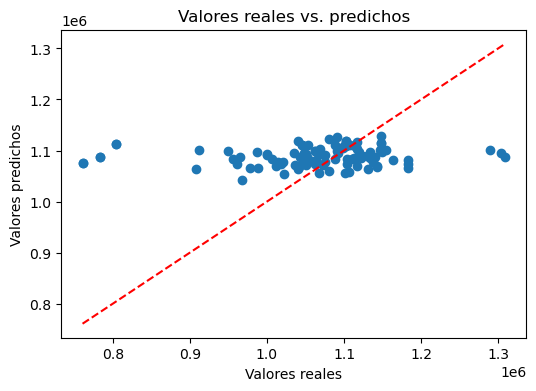

In [14]:
# Graficamos los valores reales contra los valores que predijo el modelo
plt.figure(figsize = (6, 4))
plt.scatter(y_test, y_pred)
mini = min(y_test.min(), y_pred.min())
maxi = max(y_test.max(), y_pred.max())
plt.plot([mini, maxi], [mini, maxi], "r--")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs. predichos")
plt.show()

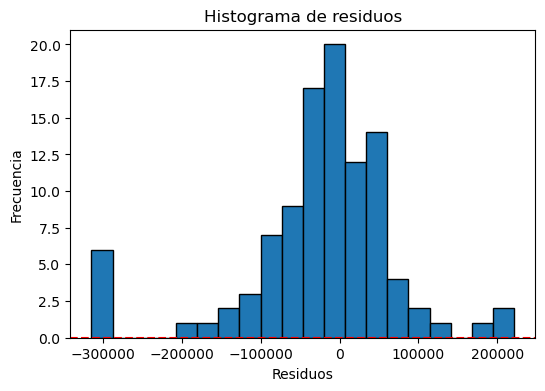

In [15]:
# Graficamos los residuos, el error por predicción
residuos = y_test - y_pred
plt.figure(figsize = (6, 4))
plt.hist(residuos, bins = 20, edgecolor = "black")
plt.axhline(0, color = "red", linestyle = "--")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Histograma de residuos")
plt.show()

Vemos que este simple modelo puede predecir decentemente la asistencia de la temporada dadas algunas estadísticas muy simples. Los outliers, que son 6 instancias del modelo quedándose corto por ~30%, se atribuyen a una disminución drástica en la asistencia del 2017 por la [relocación de los Chargers de un estadio con capacidad de 70000 a uno con capacidad de 28000](https://www.nfl.com/news/chargers-announce-decision-to-relocate-to-los-angeles-0ap3000000773179).

Así, vemos que este proyecto se puede usar para análisis predictivos más serios que conectan dos áreas del análisis deportivo: el análisis del juego y el análisis del negocio.